In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/drive/MyDrive/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


The Titanic dataset contains passenger details such as age,gender,passenger class,fare,and survival status.
The dataset has multiple numerical and categorical features.
The target vairable is "Survived".
Initial introduction was done using head(),info(), and describe() to understand structure and datatypes.

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df["Age"].fillna(df["Age"].median(),inplace=True)

/tmp/ipython-input-860536840.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)


In [ ]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

/tmp/ipython-input-548196730.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)


In [ ]:
df.drop(columns=["Cabin"],inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Data cleaning was performed to handle missing values and improve data quality.
Missing values in the "Age" column were filled using the median.
Missing values in "Embarked" column were filled using the mode.
The "cabin" column was dropped due to excessive missing values.
Duplicate values are checked and removed if present.
After cleaning,the dataset became consistent and ready for anlysis.

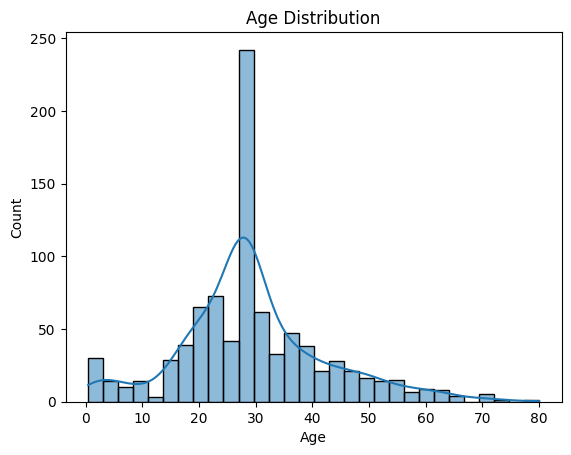

In [ ]:
plt.figure()
sns.histplot(df["Age"],kde=True)
plt.title("Age Distribution")
plt.show()

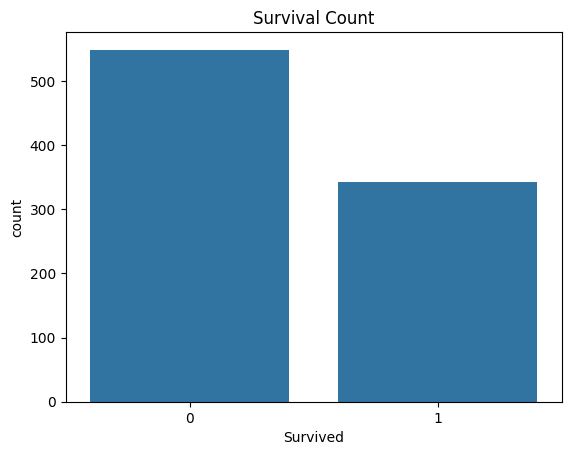

In [ ]:
plt.figure()
sns.countplot(x="Survived",data=df)
plt.title("Survival Count")
plt.show()

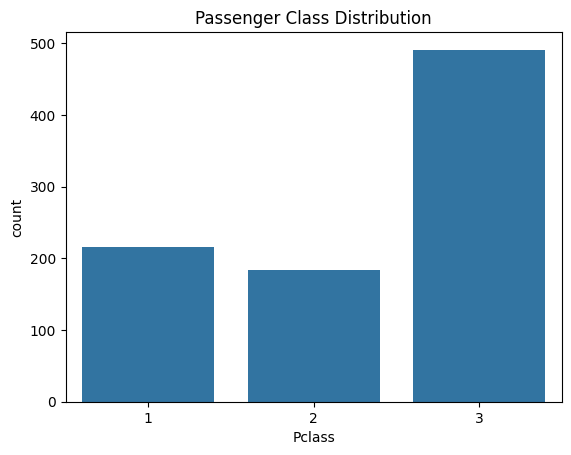

In [ ]:
plt.figure()
sns.countplot(x="Pclass",data=df)
plt.title("Passenger Class Distribution")
plt.show()

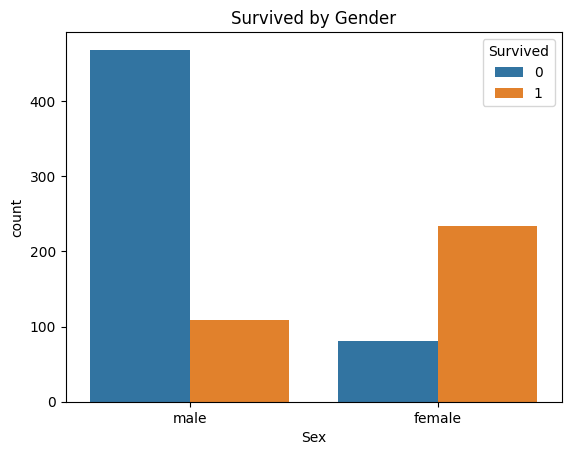

In [ ]:
plt.figure()
sns.countplot(x="Sex",hue="Survived",data=df)
plt.title("Survived by Gender")
plt.show()

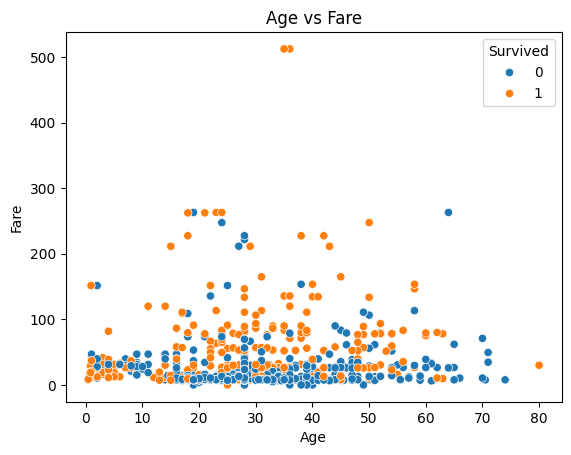

In [ ]:
plt.figure()
sns.scatterplot(x="Age",y="Fare",hue="Survived",data=df)
plt.title("Age vs Fare")
plt.show()

Unvirate and bivariate analysis were performed to understand patterns.
Unvirate Analysis:
-Age distribution shows most passengers were between 20-40 yrs old.
-Survival count shows more passengers did not survive.
-Passenger class distribution shows most passengers were in third class.
Bivariate Analysis:
-Female passengers had higher survival rates compared to males.
-First-class passengers had significantly higher survival probability.
-Fare and passengers class are related.
-Age shows weak correlation with survival.



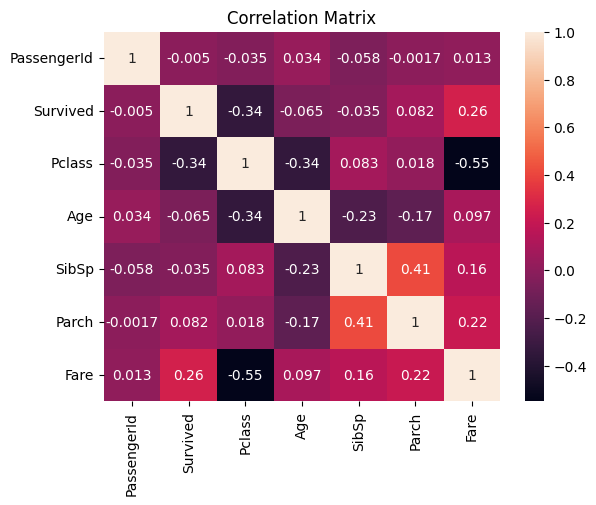

In [ ]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Matrix")
plt.show()

The correlation heatmap shows relationships between numerical features.
-Ssurvival has a negative correlation with Pclass,meaning first class passengers had higher survival chances.
-Fare has a positive correlation with survival.
-Age shows very weak correlation with survival.
Overall gender and passenger class were the strongest factors influencing survival in the Titanic Dataset.